# Introduction

In modern software systems, incident management plays a critical role in maintaining system reliability and service quality. When an issue occurs, it is recorded as an incident ticket, and resolving these incidents efficiently is essential to minimize downtime and ensure user satisfaction. However, some incidents take significantly longer to resolve than others, leading to delays, SLA violations, and increased operational costs.

In this project, we aim to develop a data-driven approach to predict whether an incident will be resolved quickly or slowly using early-stage information available at the time the incident is created. We transform event-level logs into an incident-level dataset and construct meaningful features that capture initial conditions, process complexity, and operational patterns. Using this dataset, we build classification models to predict resolution outcomes and analyze the factors that influence incident resolution time.

## Why is the problem relevant?

- Delayed incident resolution can lead to system downtime, financial loss, and poor user experience  
- Efficient incident handling is a core component of software engineering operations and DevOps practices  
- Organizations rely on prioritization and resource allocation, but these decisions are often heuristic  
- A predictive model can support early decision-making and improve operational efficiency  

## Who will benefit from addressing the problem?

- **IT support teams**: to prioritize and allocate resources more effectively  
- **System administrators / DevOps engineers**: to identify potential bottlenecks early  
- **Project managers**: to monitor and improve service performance  
- **Organizations**: to reduce downtime, improve SLA compliance, and optimize operational costs  

## Research Questions (RQs)

### RQ1 — Baseline Prediction
**How accurately can we predict whether an incident will be resolved slowly or quickly using initial incident information?**  
We build baseline classification models (Logistic Regression, Decision Tree, Random Forest) using features available at incident creation. This establishes the feasibility of the prediction task.

### RQ2 — Feature Selection
**Can we reduce the number of features while maintaining predictive performance?**  
We apply feature selection methods (Mutual Information and SelectFromModel) to identify compact subsets of features and compare their performance against the full feature set to evaluate efficiency and redundancy.

### RQ3 — Process Feature Contribution
**How much do process-related features contribute to predictive performance?**  
We remove process-related features (e.g., reassignment count, number of events, state transitions) and retrain models to assess how much predictive power is lost, isolating the importance of lifecycle-based information.

### RQ4 — Model Optimization
**How does model performance change with improved model design and parameter tuning?**  
We explore model refinement techniques (e.g., controlling model complexity such as tree depth) to improve generalization performance and evaluate the robustness of different models.


## Summary

This project not only aims to build predictive models for incident resolution time but also to provide insights into the factors that influence incident handling. By combining data transformation, feature engineering, and machine learning, we demonstrate how data-driven approaches can support better decision-making in software engineering operations.

# Data Preparation

In this section, we perform data preparation steps, including importing libraries, loading the dataset, inspecting the dataset, and validating the dataset.

## Import Libraries

In [398]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from scipy.stats import mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    make_scorer, 
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import SelectFromModel
from functools import partial


## Load Dataset 

In [399]:
# Load dataset
df = pd.read_csv("incident_event_log.csv")

df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


## Data Inspection & Validation

### Quick Overview

We check the dataset size and confirm the number of unique incidents.

In [400]:
print("Dataset shape:", df.shape)
print("Number of unique incidents:", df["number"].nunique())

Dataset shape: (141712, 36)
Number of unique incidents: 24918


### Column Names

We list all columns to understand what information is available in the original dataset.

In [401]:
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. number
2. incident_state
3. active
4. reassignment_count
5. reopen_count
6. sys_mod_count
7. made_sla
8. caller_id
9. opened_by
10. opened_at
11. sys_created_by
12. sys_created_at
13. sys_updated_by
14. sys_updated_at
15. contact_type
16. location
17. category
18. subcategory
19. u_symptom
20. cmdb_ci
21. impact
22. urgency
23. priority
24. assignment_group
25. assigned_to
26. knowledge
27. u_priority_confirmation
28. notify
29. problem_id
30. rfc
31. vendor
32. caused_by
33. closed_code
34. resolved_by
35. resolved_at
36. closed_at


### Dataset Information

We inspect data types and non-null counts for each column.

In [402]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   number                   141712 non-null  str  
 1   incident_state           141712 non-null  str  
 2   active                   141712 non-null  bool 
 3   reassignment_count       141712 non-null  int64
 4   reopen_count             141712 non-null  int64
 5   sys_mod_count            141712 non-null  int64
 6   made_sla                 141712 non-null  bool 
 7   caller_id                141712 non-null  str  
 8   opened_by                141712 non-null  str  
 9   opened_at                141712 non-null  str  
 10  sys_created_by           141712 non-null  str  
 11  sys_created_at           141712 non-null  str  
 12  sys_updated_by           141712 non-null  str  
 13  sys_updated_at           141712 non-null  str  
 14  contact_type             141712 non-null  str  

### Missing Values

We check missing values to identify columns that may need cleaning, imputation, or removal.

In [403]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

# Check missing values represented as "?"
question_mark_missing = pd.DataFrame({
    "question_mark_count": (df == "?").sum(),
    "question_mark_percent": (df == "?").mean() * 100
}).sort_values("question_mark_percent", ascending=False)

display(question_mark_missing)

,missing_count,missing_percent
number,0,0.0
incident_state,0,0.0
impact,0,0.0
urgency,0,0.0
priority,0,0.0
assignment_group,0,0.0
assigned_to,0,0.0
knowledge,0,0.0
u_priority_confirmation,0,0.0
notify,0,0.0


,question_mark_count,question_mark_percent
caused_by,141689,99.983770
vendor,141468,99.827820
cmdb_ci,141267,99.685983
rfc,140721,99.300694
problem_id,139417,98.380518
sys_created_at,53076,37.453427
sys_created_by,53076,37.453427
u_symptom,32964,23.261262
assigned_to,27496,19.402732
assignment_group,14213,10.029496


### Unique Values

We examine the number of unique values in each column to understand identifiers, categorical variables, and possible high-cardinality features.

In [404]:
unique_summary = pd.DataFrame({
    "unique_values": df.nunique()
}).sort_values("unique_values", ascending=False)

display(unique_summary)

,unique_values
sys_updated_at,50664
number,24918
opened_at,19849
resolved_at,18506
sys_created_at,11553
caller_id,5245
closed_at,2707
sys_updated_by,846
u_symptom,526
subcategory,255


### Duplicate Rows

We check whether the dataset contains fully duplicated rows.

In [405]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### Numerical Summary

We inspect summary statistics for numerical columns such as reassignment count, reopen count, and system update count.

In [406]:
display(df.describe())

,reassignment_count,reopen_count,sys_mod_count
count,141712.000000,141712.000000,141712.000000
mean,1.104197,0.021918,5.080946
std,1.734673,0.207302,7.680652
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000
50%,1.000000,0.000000,3.000000
75%,1.000000,0.000000,6.000000
max,27.000000,8.000000,129.000000


## Data Construction

In this step, the original event-level dataset was transformed into an incident-level dataset. The goal is to create one row per incident so that each incident can be used as one observation for later analysis and modeling.

### 1. Missing Value Standardization

The original dataset uses `"?"` to represent missing values. These values were replaced with `NaN` so that pandas can correctly detect and process missing data.

### 2. Removed Features

The following columns were removed because they contain too many missing values and provide little useful information:

- `caused_by`
- `vendor`
- `cmdb_ci`
- `rfc`
- `problem_id`

The following columns were removed because they are high-cardinality identifiers, have many missing values, or may introduce noise/leakage:

- `sys_created_at`: many missing values; `opened_at` is sufficient as the incident start time
- `sys_created_by`: high-cardinality user identifier
- `assigned_to`: high-cardinality user identifier with missing values
- `caller_id`: high-cardinality affected-user identifier
- `opened_by`: high-cardinality reporter identifier
- `resolved_by`: high-cardinality user identifier
- `active`: all incidents are inactice, this provides little information
- `final_state`: all incidents have the same final state, this provides little information
- `closed_code`: not useful
- `location`: hard to encode, provides little information
- `category`: hard to encode, provides little information
- `subcategory`: hard to encode, provides little information
- `u_symptom`: hard to encode, provides little information

The following column was removed because it leaks outcome information:

- `made_sla`: whether the incident met the SLA depends on the resolution outcome, so it should not be used as an input feature

### 3. Event-Level to Incident-Level Aggregation

The original dataset contains multiple rows for the same incident, where each row records an update or event. The data was grouped by `number`, which is the incident identifier, to create one row per incident.

Different columns were aggregated based on their meaning:

- Initial incident attributes were merged using the first value:
  - `opened_at`
  - `contact_type`
  - `location`
  - `category`
  - `subcategory`
  - `u_symptom`
  - `impact`
  - `urgency`
  - `priority`
  - `knowledge`
  - `u_priority_confirmation`
  - `notify`

Some of these features may change during the incident lifecycle. However, the first value is used because the project focuses on early prediction using information available near the time the incident was opened.

- Final status fields were merged using the last value:
  - `incident_state`, renamed as `final_state`
  - `active`
  - `resolved_at`
  - `closed_at`

These describe the final recorded state or final timestamps of the incident.

- Cumulative count fields were merged using the maximum value:
  - `reassignment_count`
  - `reopen_count`
  - `sys_mod_count`

These fields increase over time, so the maximum value represents the final total count for each incident.

### 4. New Process Features Created

Several new features were created to describe the complexity of the incident lifecycle:

- `num_assignment_groups`: created from `assignment_group`; counts how many different support groups handled the incident
- `num_unique_states`: created from `incident_state`; counts how many different states the incident went through
- `num_events`: created from the number of rows per `number`; counts how many event records exist for each incident

### 5. Binary and Ordinal Encoding

Several binary features were converted into 0/1 format:

- `notify`: `Send Email` = 1, `Do Not Notify` = 0
- `knowledge`: True = 1, False = 0
- `u_priority_confirmation`: True = 1, False = 0
- `active`: True = 1, False = 0

The ordinal features `impact`, `urgency`, and `priority` were converted into numeric values after checking their actual values. Higher severity values are encoded with larger numbers when possible.

### 6. Target Variable Created

The main outcome variable was created from:

- `resolved_at`
- `opened_at`

The new variable is:

- `resolution_time_hours = resolved_at - opened_at`

This measures how many hours it took to resolve each incident.

To define a meaningful classification target while avoiding data leakage, the dataset was first split into training and testing sets. The resolution time thresholds were then computed **only from the training data**, ensuring that no information from the test set influences the target definition.

Instead of using a single global median, a **priority-based threshold** was used. This reflects the fact that expected resolution time varies depending on incident severity.

The median resolution time was calculated separately for each priority level in the training set:

- Priority 1: 4.16 hours  
- Priority 2: 22.05 hours  
- Priority 3: 49.22 hours  
- Priority 4: 49.13 hours

A binary target variable was also created:

- `slow_resolution`

An incident is labeled as **slow** if its resolution time exceeds the median resolution time of incidents with the same priority level, based on the training data.

### 7. New Time and Process Intensity Features Created

Several features were created from `opened_at` before raw timestamps were removed:

- `opened_hour`: hour when the incident was opened
- `opened_dayofweek`: day of week when the incident was opened
- `opened_month`: month when the incident was opened
- `opened_on_weekend`: whether the incident was opened on Saturday or Sunday

Additional normalized and binary process features were created:

- `mod_per_event`: created from `sys_mod_count / num_events`
- `reassign_per_event`: created from `reassignment_count / num_events`
- `was_reassigned`: whether `reassignment_count > 0`
- `was_reopened`: whether `reopen_count > 0`
- `multi_group`: whether more than one assignment group was involved

After these features were created, raw timestamp columns were removed because they are either no longer needed or would leak target information.

In [407]:
# ==============================
# 1. Copy & Basic Cleaning
# ==============================

df_work = df.copy()
df_work = df_work.replace("?", np.nan)


# ==============================
# 2. Drop Columns Based on Missingness, IDs, and Leakage
# ==============================

high_missing_cols = [
    "caused_by",
    "vendor",
    "cmdb_ci",
    "rfc",
    "problem_id"
]

drop_id_or_low_value_cols = [
    "sys_created_at",
    "sys_created_by",
    "assigned_to",
    "caller_id",
    "opened_by",
    "resolved_by"
]

leakage_cols = [
    "made_sla",
    "closed_code"
]

df_work = df_work.drop(
    columns=high_missing_cols + drop_id_or_low_value_cols + leakage_cols
)


# ==============================
# 3. Convert Time Columns
# ==============================

time_cols = ["opened_at", "sys_updated_at", "resolved_at", "closed_at"]

for col in time_cols:
    df_work[col] = pd.to_datetime(df_work[col], errors="coerce", dayfirst=True)

df_work = df_work.sort_values(["number", "sys_updated_at"])


# ==============================
# 4. Consistency Check
# ==============================

consistency_check = df_work.groupby("number").nunique()

constant_cols = consistency_check.columns[consistency_check.max() == 1]
changing_cols = consistency_check.columns[consistency_check.max() > 1]

print("Constant columns:")
print(list(constant_cols))

print("\nChanging columns:")
print(list(changing_cols))


# ==============================
# 5. Aggregate Event-Level Data to Incident-Level Data
# ==============================

incident_df = df_work.groupby("number").agg(

    # ---- Initial incident attributes ----
    # These features may change later, but first value represents what is known early
    opened_at=("opened_at", "first"),
    contact_type=("contact_type", "first"),
    location=("location", "first"),
    category=("category", "first"),
    subcategory=("subcategory", "first"),
    u_symptom=("u_symptom", "first"),
    impact=("impact", "first"),
    urgency=("urgency", "first"),
    priority=("priority", "first"),
    knowledge=("knowledge", "first"),
    u_priority_confirmation=("u_priority_confirmation", "first"),
    notify=("notify", "first"),

    # ---- Final state and final timestamps ----
    # These are used for target construction or descriptive analysis
    final_state=("incident_state", "last"),
    active=("active", "last"),
    resolved_at=("resolved_at", "last"),
    closed_at=("closed_at", "last"),

    # ---- Cumulative counters ----
    reassignment_count=("reassignment_count", "max"),
    reopen_count=("reopen_count", "max"),
    sys_mod_count=("sys_mod_count", "max"),

    # ---- Process behavior ----
    num_assignment_groups=("assignment_group", "nunique"),
    num_unique_states=("incident_state", "nunique"),

    # ---- Event count ----
    num_events=("number", "size")

).reset_index()


# ==============================
# 6. Inspect Binary and Ordinal Feature Values
# ==============================

binary_like_cols = ["notify", "knowledge", "u_priority_confirmation", "active"]

for col in binary_like_cols:
    print(f"\n{col}:")
    print(incident_df[col].value_counts(dropna=False))

ordinal_cols = ["impact", "urgency", "priority"]

for col in ordinal_cols:
    print(f"\n{col}:")
    print(incident_df[col].value_counts(dropna=False))


# ==============================
# 7. Encode Binary Features
# ==============================

incident_df["notify"] = (incident_df["notify"] == "Send Email").astype(int)

for col in ["knowledge", "u_priority_confirmation"]:
    incident_df[col] = incident_df[col].astype(int)

# Drop active and final_state because they have no variation at the incident level
incident_df = incident_df.drop(columns=["active", "final_state"])


# ==============================
# 8. Encode Ordinal Features
# ==============================

def encode_ordinal_from_prefix(series):
    """
    Convert labels such as '1 - High' or '4 - Low' into ordered numeric values.
    The numeric prefix is extracted first.
    The scale is reversed so larger values represent higher severity.
    """
    prefix_num = series.astype(str).str.extract(r"^(\d+)")[0].astype(float)

    if prefix_num.isna().any():
        missing_count = prefix_num.isna().sum()
        raise ValueError(f"{series.name} has {missing_count} values that could not be ordinal-encoded.")

    max_level = int(prefix_num.max())
    return max_level + 1 - prefix_num.astype(int)

for col in ["impact", "urgency", "priority"]:
    incident_df[col] = encode_ordinal_from_prefix(incident_df[col])


# ==============================
# 9. Time-Based Feature Engineering
# ==============================

incident_df["resolution_time_hours"] = (
    incident_df["resolved_at"] - incident_df["opened_at"]
).dt.total_seconds() / 3600

incident_df["close_time_hours"] = (
    incident_df["closed_at"] - incident_df["opened_at"]
).dt.total_seconds() / 3600

incident_df["opened_hour"] = incident_df["opened_at"].dt.hour
incident_df["opened_dayofweek"] = incident_df["opened_at"].dt.dayofweek
incident_df["opened_month"] = incident_df["opened_at"].dt.month
incident_df["opened_on_weekend"] = incident_df["opened_dayofweek"].isin([5, 6]).astype(int)


# ==============================
# 10. Process Intensity Features
# ==============================

incident_df["mod_per_event"] = incident_df["sys_mod_count"] / incident_df["num_events"]
incident_df["reassign_per_event"] = incident_df["reassignment_count"] / incident_df["num_events"]

incident_df["was_reassigned"] = (incident_df["reassignment_count"] > 0).astype(int)
incident_df["was_reopened"] = (incident_df["reopen_count"] > 0).astype(int)
incident_df["multi_group"] = (incident_df["num_assignment_groups"] > 1).astype(int)


# ==============================
# 11. Clean Outcome Variables
# ==============================

incident_df = incident_df.dropna(subset=["resolution_time_hours"])
incident_df = incident_df[incident_df["resolution_time_hours"] >= 0].copy()


# ==============================
# 12. Remove Raw Timestamp Features & Useless Features
# ==============================

# Raw timestamps are removed after creating duration and opening-time features
incident_df = incident_df.drop(columns=["opened_at", "resolved_at", "closed_at"])
incident_df = incident_df.drop(columns=["location", "category", "subcategory", "u_symptom"])


# ==============================
# 13. Split Before Defining Target
# ==============================

train_df, test_df = train_test_split(
    incident_df,
    test_size=0.2,
    random_state=42
)


# ==============================
# 14. Define Priority-Based Threshold from Training Data Only
# ==============================

# Threshold is computed only from training data to avoid data leakage
priority_thresholds = train_df.groupby("priority")["resolution_time_hours"].median()

print("Priority-based resolution thresholds from training data:")
print(priority_thresholds)

# Apply the training thresholds to both train and test sets
train_df = train_df.copy()
test_df = test_df.copy()

train_df["slow_resolution"] = (
    train_df["resolution_time_hours"] >
    train_df["priority"].map(priority_thresholds)
).astype(int)

test_df["slow_resolution"] = (
    test_df["resolution_time_hours"] >
    test_df["priority"].map(priority_thresholds)
).astype(int)


# ==============================
# 15. Create Combined Dataset for EDA
# ==============================

# This combined dataset includes the target and outcome variables for EDA only
eda_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)


# ==============================
# 16. Create Modeling Datasets
# ==============================

# These columns are removed from model features to avoid leakage
model_drop_cols = [
    "number",
    "resolution_time_hours",
    "close_time_hours",
    "slow_resolution"
]

X_train = train_df.drop(columns=model_drop_cols)
y_train = train_df["slow_resolution"]

X_test = test_df.drop(columns=model_drop_cols)
y_test = test_df["slow_resolution"]


# ==============================
# 17. Final Check
# ==============================

print("Incident-level dataset shape:", incident_df.shape)
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
print("EDA dataset shape:", eda_df.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

print("\nX_train columns:")
print(list(X_train.columns))

display(eda_df.head())

Constant columns:
['opened_at', 'notify', 'resolved_at', 'closed_at']

Changing columns:
['incident_state', 'active', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'sys_updated_by', 'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'impact', 'urgency', 'priority', 'assignment_group', 'knowledge', 'u_priority_confirmation']

notify:
notify
Do Not Notify    24882
Send Email          36
Name: count, dtype: int64

knowledge:
knowledge
False    21363
True      3555
Name: count, dtype: int64

u_priority_confirmation:
u_priority_confirmation
False    24897
True        21
Name: count, dtype: int64

active:
active
False    24918
Name: count, dtype: int64

impact:
impact
2 - Medium    23906
3 - Low         726
1 - High        286
Name: count, dtype: int64

urgency:
urgency
2 - Medium    23848
3 - Low         675
1 - High        395
Name: count, dtype: int64

priority:
priority
3 - Moderate    23681
4 - Low           741
2 - High          311
1 - Criti

,number,contact_type,impact,urgency,priority,knowledge,u_priority_confirmation,notify,reassignment_count,reopen_count,sys_mod_count,num_assignment_groups,num_unique_states,num_events,resolution_time_hours,close_time_hours,opened_hour,opened_dayofweek,opened_month,opened_on_weekend,mod_per_event,reassign_per_event,was_reassigned,was_reopened,multi_group,slow_resolution
0,INC0011893,Phone,2,2,2,0,0,0,3,0,14,3,5,12,362.383333,482.800000,11,0,3,0,1.166667,0.25,1,0,1,1
1,INC0018233,Phone,2,2,2,0,0,0,0,0,4,1,4,5,24.700000,145.500000,14,1,4,0,0.800000,0.00,0,0,0,1
2,INC0006779,Phone,2,2,2,0,0,0,0,0,4,1,3,5,0.333333,244.483333,14,0,3,0,0.800000,0.00,0,0,0,0
3,INC0004342,Phone,2,2,2,1,0,0,4,0,11,2,5,10,237.366667,388.650000,14,1,3,0,1.100000,0.40,1,0,1,1
4,INC0029999,Phone,2,2,2,0,0,0,0,0,2,1,3,3,0.100000,120.950000,16,0,5,0,0.666667,0.00,0,0,0,0


# Exploratory Data Analysis (EDA)

This section analyzes the prepared incident-level dataset to understand target distribution, feature behavior, and relationships between features and the target variable. The goal is to validate assumptions and identify informative patterns before modeling.

## Class Distribution of Target Variable

The class distribution is approximately balanced due to the median-based threshold. This ensures that classification models are not biased toward one class.

slow_resolution
0    0.500813
1    0.499187
Name: proportion, dtype: float64
slow_resolution
0    11700
1    11662
Name: count, dtype: int64


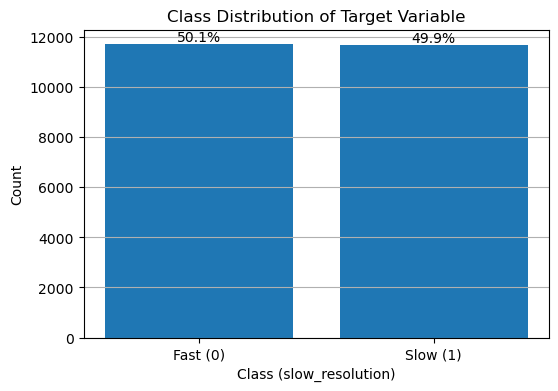

In [436]:
# Check class balance
class_dist = eda_df["slow_resolution"].value_counts(normalize=True)
print(class_dist)

# Absolute counts
print(eda_df["slow_resolution"].value_counts())

# Class distribution
counts = eda_df["slow_resolution"].value_counts()
proportions = eda_df["slow_resolution"].value_counts(normalize=True)

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index.astype(str), counts.values)

# Add percentage labels on top
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{proportions.iloc[i]*100:.1f}%",
        ha='center',
        va='bottom'
    )

plt.xlabel("Class (slow_resolution)")
plt.ylabel("Count")
plt.title("Class Distribution of Target Variable")
plt.xticks([0,1], ["Fast (0)", "Slow (1)"])
plt.grid(axis='y')
plt.show()

## Descriptive Statistics of Numerical Features

This provides an overview of feature distributions, including central tendency and spread. Particular attention should be given to skewness in variables such as `resolution_time_hours` and count-based features.

In [409]:
eda_df.describe()

,impact,urgency,priority,knowledge,u_priority_confirmation,notify,reassignment_count,reopen_count,sys_mod_count,num_assignment_groups,num_unique_states,num_events,resolution_time_hours,close_time_hours,opened_hour,opened_dayofweek,opened_month,opened_on_weekend,mod_per_event,reassign_per_event,was_reassigned,was_reopened,multi_group,slow_resolution
count,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000,23362.000000
mean,1.985446,1.991910,2.001712,0.146520,0.000899,0.001541,1.001798,0.014126,7.061639,1.588049,3.600591,5.931470,178.171582,325.355403,11.837685,1.960149,3.955012,0.047385,1.093003,0.123527,0.486217,0.011728,0.409682,0.499187
std,0.197047,0.204553,0.269120,0.353634,0.029969,0.039226,1.604245,0.153626,8.700008,0.906185,0.728093,3.670037,532.787772,547.757068,4.069537,1.588235,0.972366,0.212465,1.090487,0.149078,0.499821,0.107663,0.491786,0.500010
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,2.000000,0.000000,0.033333,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,3.000000,3.000000,0.416667,121.083333,9.000000,1.000000,3.000000,0.000000,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,3.000000,5.000000,22.100000,150.133333,11.000000,2.000000,4.000000,0.000000,0.833333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,8.000000,2.000000,4.000000,7.000000,148.479167,335.733333,15.000000,3.000000,5.000000,0.000000,1.000000,0.250000,1.000000,0.000000,1.000000,1.000000
max,3.000000,3.000000,4.000000,1.000000,1.000000,1.000000,27.000000,8.000000,129.000000,8.000000,7.000000,58.000000,8070.166667,8190.616667,23.000000,6.000000,12.000000,1.000000,25.750000,0.800000,1.000000,1.000000,1.000000,1.000000


## Correlation Between Numerical Features

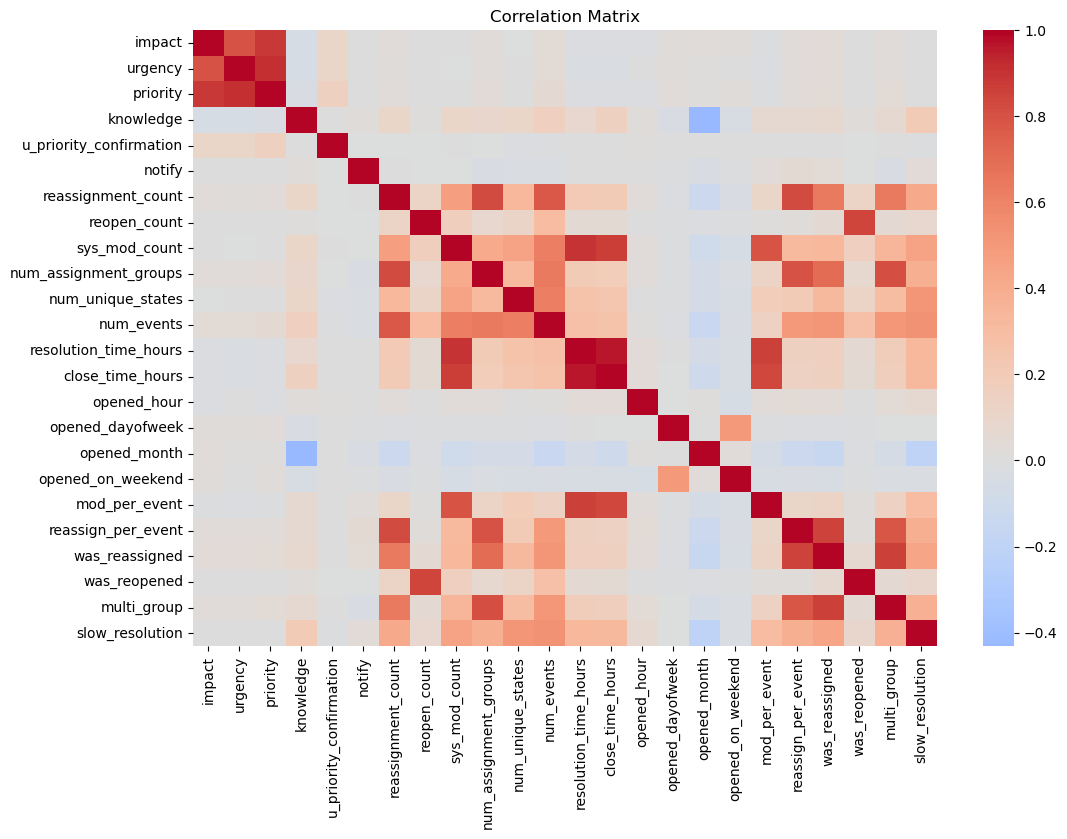

In [410]:
corr_matrix = eda_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## Top Correlated Feature Pairs

Highly correlated feature pairs may indicate redundancy or shared underlying processes. These relationships are useful for feature selection and model simplification.

In [411]:
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print(corr_pairs.head(10))

resolution_time_hours  close_time_hours         0.964905
urgency                priority                 0.905379
sys_mod_count          resolution_time_hours    0.899515
impact                 priority                 0.885992
sys_mod_count          close_time_hours         0.866487
resolution_time_hours  mod_per_event            0.864338
was_reassigned         multi_group              0.856359
reassign_per_event     was_reassigned           0.851790
reopen_count           was_reopened             0.844049
close_time_hours       mod_per_event            0.833641
dtype: float64


## Correlation of Features with Target

This identifies features most strongly associated with slow resolution. Process-related features such as reassignment and event counts are expected to show meaningful relationships.

num_events                 0.531838
num_unique_states          0.515825
sys_mod_count              0.450896
was_reassigned             0.446320
reassignment_count         0.413049
reassign_per_event         0.389708
num_assignment_groups      0.387266
multi_group                0.374500
resolution_time_hours      0.329645
close_time_hours           0.326416
mod_per_event              0.307106
knowledge                  0.198824
was_reopened               0.091622
reopen_count               0.079839
opened_hour                0.061006
notify                     0.034984
urgency                    0.008515
priority                   0.004464
impact                     0.003356
opened_dayofweek          -0.005081
u_priority_confirmation   -0.009950
opened_on_weekend         -0.026030
opened_month              -0.205614
Name: slow_resolution, dtype: float64


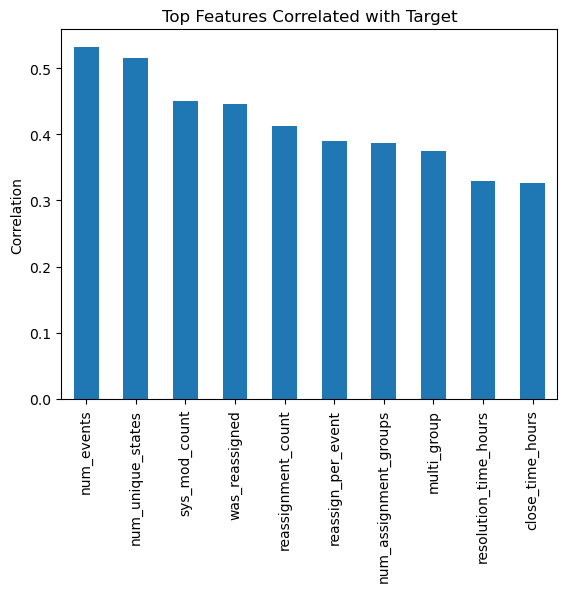

In [412]:
target_corr = corr_matrix["slow_resolution"].drop("slow_resolution").sort_values(ascending=False)
print(target_corr)

# Plot top features
top_features = target_corr.abs().sort_values(ascending=False).head(10)

top_features.plot(kind="bar")
plt.title("Top Features Correlated with Target")
plt.ylabel("Correlation")
plt.show()

## Statistical Testing (Mann–Whitney U Test)

H0: The distribution of the feature is the same for fast and slow incidents

H1: The distribution of the feature differs between fast and slow incidents

The Mann–Whitney U test shows that key process-related features such as system modifications, number of events, and reassignment behavior differ significantly between fast and slow incidents. This indicates that these features are strong predictors of resolution time.

In [413]:
numeric_cols = eda_df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop(["slow_resolution", "resolution_time_hours", "close_time_hours"])

results = []

for col in numeric_cols:
    group1 = eda_df[eda_df["slow_resolution"] == 0][col]
    group2 = eda_df[eda_df["slow_resolution"] == 1][col]
    
    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")
    results.append((col, p))

mw_df = pd.DataFrame(results, columns=["feature", "p_value"]).sort_values("p_value")
print(mw_df.head(10))

                  feature        p_value
8           sys_mod_count   0.000000e+00
15         was_reassigned   0.000000e+00
14     reassign_per_event   0.000000e+00
13          mod_per_event   0.000000e+00
11             num_events   0.000000e+00
10      num_unique_states   0.000000e+00
9   num_assignment_groups   0.000000e+00
17            multi_group   0.000000e+00
6      reassignment_count   0.000000e+00
3               knowledge  7.708981e-203


## Feature Distributions by Target

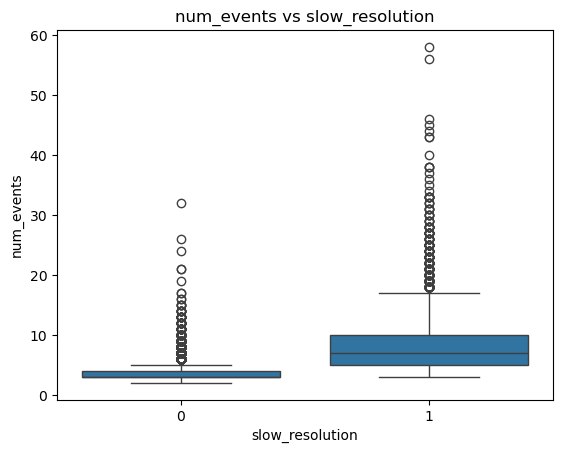

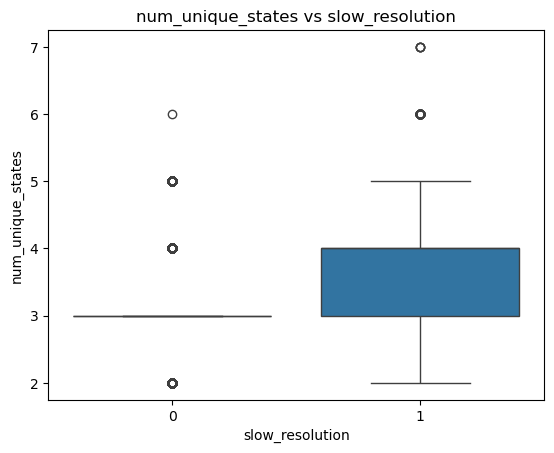

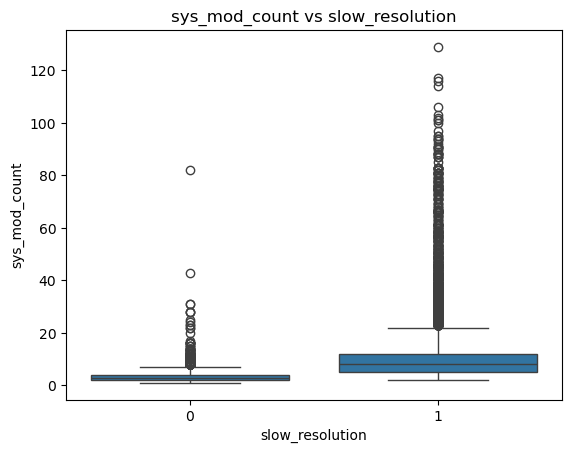

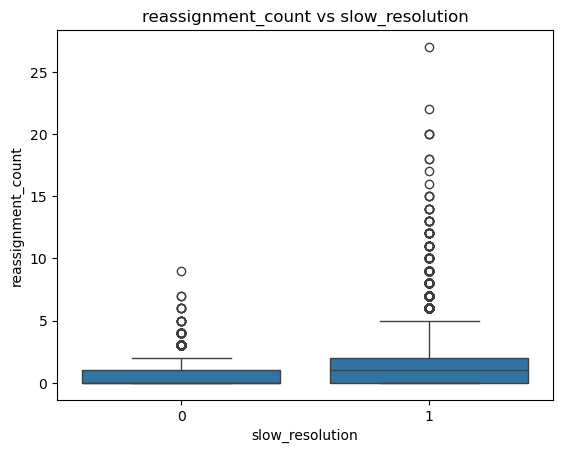

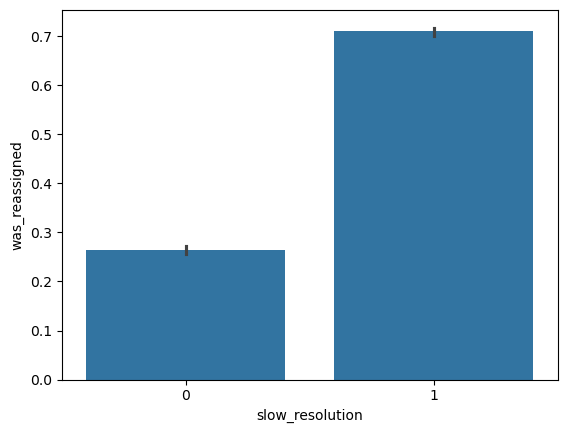

In [414]:
key_features = [
    "num_events",
    "num_unique_states",
    "sys_mod_count",
    "reassignment_count"
]

for col in key_features:
    sns.boxplot(x="slow_resolution", y=col, data=eda_df)
    plt.title(f"{col} vs slow_resolution")
    plt.show()

sns.barplot(x="slow_resolution", y="was_reassigned", data=eda_df)
plt.show()

## Distribution of Resolution Time

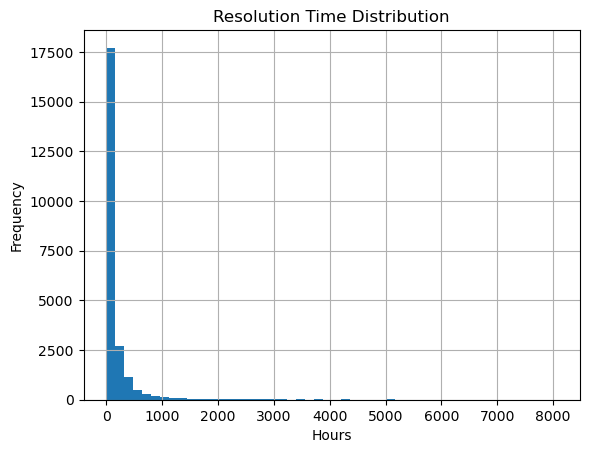

In [415]:
eda_df["resolution_time_hours"].hist(bins=50)
plt.title("Resolution Time Distribution")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

# Baseline Model

## Experimental Setup

In this section, we prepare the incident-level training and testing data for modeling. The target variable is `slow_resolution`, and the input features are stored in `X_train` and `X_test`.

The preprocessing steps are fitted only on the training set and then applied to the test set to avoid data leakage.

- The incident identifier `number` is removed before modeling and is not encoded or scaled.
- The only remaining categorical feature is `contact_type`, which is one-hot encoded because its categories have no natural order.
- Numeric features are imputed with the training median and scaled with `StandardScaler`.
- Missing values are checked before preprocessing. Even if no missing values remain, imputation is kept in the pipeline for robustness and is fitted only on the training set.
- Evaluation metrics function is defined to have accuracy, Marco F1, Weighted F1, Minority recall, ROC-AUC, PR-AUC.

In [416]:
# ==============================
# 1. Check Missing Values Before Preprocessing
# ==============================

print("Missing values in X_train:")
display(X_train.isna().sum()[X_train.isna().sum() > 0])

print("Missing values in X_test:")
display(X_test.isna().sum()[X_test.isna().sum() > 0])


# ==============================
# 2. Define Feature Types
# ==============================

categorical_cols = ["contact_type"]
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


# ==============================
# 3. Build Preprocessing Pipelines
# ==============================

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)


# ==============================
# 4. Fit Preprocessing on Training Set Only
# ==============================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

onehot_feature_names = preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"].get_feature_names_out(categorical_cols)

final_feature_names = numeric_cols + list(onehot_feature_names)

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=final_feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=final_feature_names,
    index=X_test.index
)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

display(X_train_processed.head())

# ==============================
# 4. Evaluation Function
# ==============================

def evaluate_model(model, X_train, X_test, y_train, y_test, class_names=None):
    if class_names is None:
        class_names = ["Fast", "Slow"]

    # Fit model
    model.fit(X_train, y_train)

    # Predict labels
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Predict probabilities if supported
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    # Metrics
    training_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    macro_f1 = f1_score(y_test, y_test_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    pr_auc = average_precision_score(y_test, y_proba) if y_proba is not None else None

    # Print summary
    print(f"\nModel: {model.__class__.__name__}")
    print(f"Number of Features: {X_train.shape[1]}")
    print(f"Training Accuracy: {training_accuracy:.3f}")
    print(f"Test Accuracy: {test_accuracy:.3f}")
    print(f"Macro F1: {macro_f1:.3f}")
    print(f"Weighted F1: {weighted_f1:.3f}")

    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.3f}")
    if pr_auc is not None:
        print(f"PR-AUC: {pr_auc:.3f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred, target_names=class_names))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        display_labels=class_names,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {model.__class__.__name__}")
    plt.show()

    return {
        "model": model.__class__.__name__,
        "num_features": X_train.shape[1],
        "training_accuracy": training_accuracy,
        "test_accuracy": test_accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

Missing values in X_train:


Series([], dtype: int64)

Missing values in X_test:


Series([], dtype: int64)

Categorical columns: ['contact_type']
Numeric columns: ['impact', 'urgency', 'priority', 'knowledge', 'u_priority_confirmation', 'notify', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'num_assignment_groups', 'num_unique_states', 'num_events', 'opened_hour', 'opened_dayofweek', 'opened_month', 'opened_on_weekend', 'mod_per_event', 'reassign_per_event', 'was_reassigned', 'was_reopened', 'multi_group']
Processed training shape: (18689, 25)
Processed testing shape: (4673, 25)


,impact,urgency,priority,knowledge,u_priority_confirmation,notify,reassignment_count,reopen_count,sys_mod_count,num_assignment_groups,num_unique_states,num_events,opened_hour,opened_dayofweek,opened_month,opened_on_weekend,mod_per_event,reassign_per_event,was_reassigned,was_reopened,multi_group,contact_type_Direct opening,contact_type_Email,contact_type_Phone,contact_type_Self service
7829,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,1.244941,-0.094362,0.803895,1.558726,1.933904,1.657855,-0.203890,-1.235494,-0.979324,-0.224272,0.070056,0.850277,1.029489,-0.109141,1.198465,0.0,0.0,1.0,0.0
12426,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,-0.621821,-0.094362,-0.352865,-0.650513,0.553989,-0.252593,0.535917,-0.605991,0.048911,-0.224272,-0.272433,-0.828119,-0.971356,-0.109141,-0.834401,0.0,0.0,1.0,0.0
4253,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,-0.621821,-0.094362,-0.352865,-0.650513,-0.825926,-0.252593,0.535917,-1.235494,-0.979324,-0.224272,-0.272433,-0.828119,-0.971356,-0.109141,-0.834401,0.0,0.0,1.0,0.0
2789,0.071157,0.034638,-0.010361,2.403391,-0.031901,-0.040097,1.867196,-0.094362,0.456867,0.454106,1.933904,1.112012,0.535917,-0.605991,-0.979324,-0.224272,0.007785,1.857316,1.029489,-0.109141,1.198465,0.0,0.0,1.0,0.0
21347,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,-0.621821,-0.094362,-0.584217,-0.650513,-0.825926,-0.798436,1.029122,-1.235494,1.077146,-0.224272,-0.396975,-0.828119,-0.971356,-0.109141,-0.834401,0.0,0.0,1.0,0.0


## Logistic Regression

Logistic Regression is used as the baseline model because this is a simple linear and interpretable model with low risk of overfitting, chosen as a baseline to evaluate whether the engineered features alone can effectively predict the target.


Model: LogisticRegression
Number of Features: 25
Training Accuracy: 0.859
Test Accuracy: 0.856
Macro F1: 0.856
Weighted F1: 0.856
ROC-AUC: 0.931
PR-AUC: 0.928

Classification Report:
              precision    recall  f1-score   support

        Fast       0.85      0.87      0.86      2355
        Slow       0.86      0.84      0.85      2318

    accuracy                           0.86      4673
   macro avg       0.86      0.86      0.86      4673
weighted avg       0.86      0.86      0.86      4673



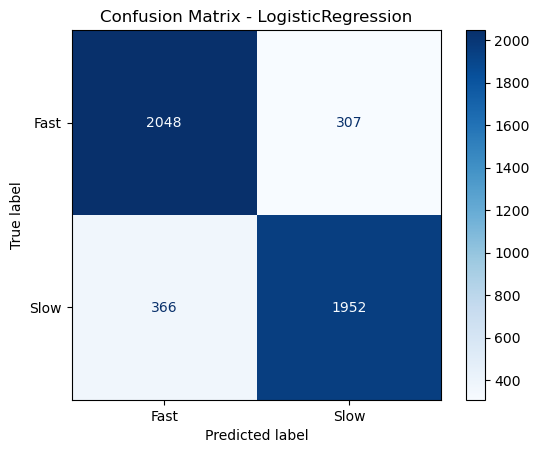

In [417]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

results_log_reg = evaluate_model(
    log_reg,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Decision Tree

This is a nonlinear, rule-based model that captures feature interactions, chosen to test whether moderate model complexity improves performance over linear methods.


Model: DecisionTreeClassifier
Number of Features: 25
Training Accuracy: 0.861
Test Accuracy: 0.854
Macro F1: 0.854
Weighted F1: 0.854
ROC-AUC: 0.928
PR-AUC: 0.924

Classification Report:
              precision    recall  f1-score   support

        Fast       0.86      0.84      0.85      2355
        Slow       0.84      0.86      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



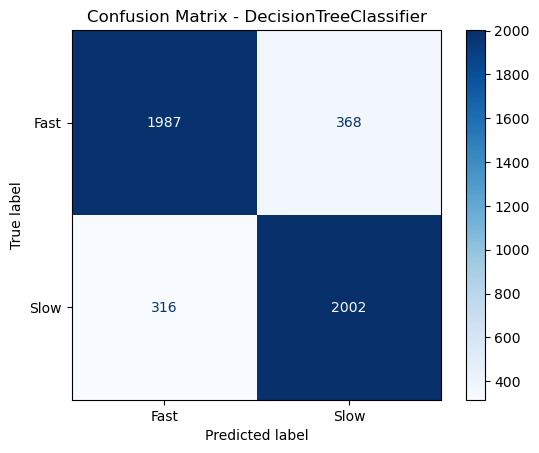

In [418]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

results_decision_tree = evaluate_model(
    decision_tree,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Random Forest

This is an ensemble of decision trees that models complex nonlinear relationships and interactions, chosen to assess whether higher model capacity can further improve predictive performance.


Model: RandomForestClassifier
Number of Features: 25
Training Accuracy: 0.861
Test Accuracy: 0.853
Macro F1: 0.853
Weighted F1: 0.853
ROC-AUC: 0.934
PR-AUC: 0.937

Classification Report:
              precision    recall  f1-score   support

        Fast       0.87      0.84      0.85      2355
        Slow       0.84      0.87      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



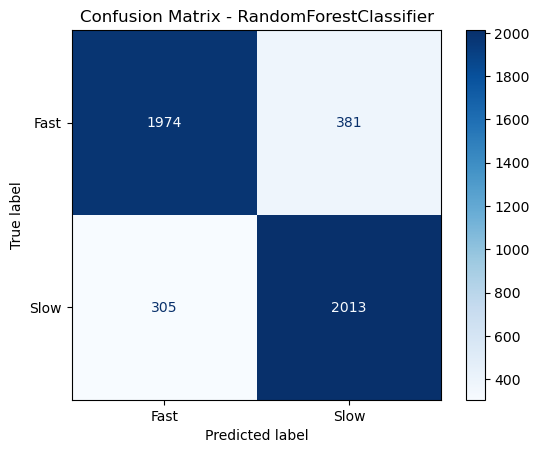

In [419]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=6,
    n_jobs=-1
)

results_random_forest = evaluate_model(
    random_forest,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

In terms of overall performance, all three models achieve very similar results. Logistic Regression slightly outperforms the others with the highest test accuracy (~0.856) and Macro F1 (~0.856), followed closely by the Decision Tree and Random Forest. ROC-AUC values remain consistently high (~0.92–0.93) across all models, indicating strong discriminative ability. The comparable performance across models suggests that the engineered features already capture the essential structure of the data, and that increasing model complexity beyond a certain point does not yield significant gains.

In [420]:
baseline_results = pd.DataFrame([
    results_log_reg,
    results_decision_tree,
    results_random_forest
])

baseline_results.insert(0, "feature_set", "Baseline")
baseline_results

,feature_set,model,num_features,training_accuracy,test_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,Baseline,LogisticRegression,25,0.858954,0.855981,0.855920,0.855944,0.930571,0.927947
1,Baseline,DecisionTreeClassifier,25,0.861362,0.853627,0.853626,0.853622,0.927969,0.923940
2,Baseline,RandomForestClassifier,25,0.861095,0.853199,0.853189,0.853179,0.934228,0.937352


# Feature Selection

After building baseline models with all transformed features, feature selection is used to evaluate whether a smaller feature set can maintain similar predictive performance. This is useful because the EDA showed that several process-related features are correlated and may contain redundant information.

In this project, two feature selection methods are applied:

1. Mutual Information
2. SelectFromModel

The selected feature sets will later be compared against the all-feature baseline models.

## Mutual Information

Mutual Information is a filter-based feature selection method. It measures how much information each feature provides about the target variable, without relying on a specific classifier.

**Why we choose it:**
- It can capture nonlinear relationships between individual features and the target.
- It is model-independent, so it provides a neutral feature ranking.
- It is useful for identifying informative features before model training.

**Pros:**
- Captures nonlinear feature-target relationships.
- Simple and fast to apply.
- Does not depend on one specific model.

**Cons:**
- Evaluates each feature independently.
- Does not handle correlated/redundant features well.
- May select multiple features that contain similar information.

Best CV weighted F1: 0.8588
Chosen k: 10


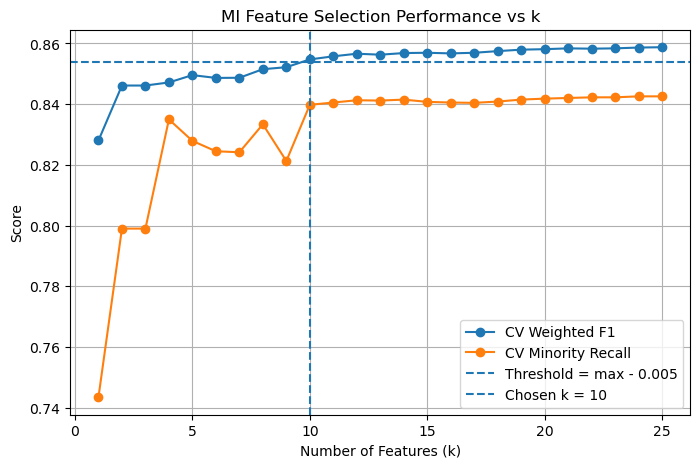

Raw selected features by Mutual Information:
['reassignment_count', 'sys_mod_count', 'num_assignment_groups', 'num_unique_states', 'num_events', 'opened_month', 'mod_per_event', 'reassign_per_event', 'was_reassigned', 'multi_group']

Selected features after contact_type group expansion:
['reassignment_count', 'sys_mod_count', 'num_assignment_groups', 'num_unique_states', 'num_events', 'opened_month', 'mod_per_event', 'reassign_per_event', 'was_reassigned', 'multi_group']

Raw selected feature count: 10
Expanded selected feature count: 10


,reassignment_count,sys_mod_count,num_assignment_groups,num_unique_states,num_events,opened_month,mod_per_event,reassign_per_event,was_reassigned,multi_group
7829,1.244941,0.803895,1.558726,1.933904,1.657855,-0.979324,0.070056,0.850277,1.029489,1.198465
12426,-0.621821,-0.352865,-0.650513,0.553989,-0.252593,0.048911,-0.272433,-0.828119,-0.971356,-0.834401
4253,-0.621821,-0.352865,-0.650513,-0.825926,-0.252593,-0.979324,-0.272433,-0.828119,-0.971356,-0.834401
2789,1.867196,0.456867,0.454106,1.933904,1.112012,-0.979324,0.007785,1.857316,1.029489,1.198465
21347,-0.621821,-0.584217,-0.650513,-0.825926,-0.798436,1.077146,-0.396975,-0.828119,-0.971356,-0.834401



Previously detected high-correlation pairs still present after MI selection:
was_reassigned -- multi_group: correlation = 0.8590
reassign_per_event -- was_reassigned: correlation = 0.8525


In [421]:


# -----------------------------
# Helper: expand one-hot groups
# -----------------------------
def expand_onehot_groups(selected_features, all_features):
    selected_features = set(selected_features)
    all_features = list(all_features)

    group_prefixes = [
        "contact_type_",
    ]

    expanded_features = set(selected_features)

    for prefix in group_prefixes:
        group_cols = [col for col in all_features if col.startswith(prefix)]

        if any(col in selected_features for col in group_cols):
            expanded_features.update(group_cols)

    # Keep original column order
    return [col for col in all_features if col in expanded_features]


# -----------------------------
# Mutual Information setup
# -----------------------------
mi_score = partial(mutual_info_classif, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "weighted_f1": "f1_weighted",
    "minority_recall": make_scorer(recall_score, pos_label=1),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}


# -----------------------------
# Search over k using training data only
# -----------------------------
max_k = min(45, X_train_processed.shape[1])
k_values = list(range(1, max_k + 1))

mi_results = []

for k in k_values:
    pipe = Pipeline(steps=[
        ("select", SelectKBest(score_func=mi_score, k=k)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])

    cv_res = cross_validate(
        pipe,
        X_train_processed,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    mi_results.append({
        "k": k,
        "weighted_f1": np.mean(cv_res["test_weighted_f1"]),
        "minority_recall": np.mean(cv_res["test_minority_recall"]),
        "roc_auc": np.mean(cv_res["test_roc_auc"]),
        "pr_auc": np.mean(cv_res["test_pr_auc"]),
    })

mi_df = pd.DataFrame(mi_results)


# -----------------------------
# Choose k using tolerance rule
# -----------------------------
epsilon = 0.005
max_score = mi_df["weighted_f1"].max()
threshold = max_score - epsilon

candidate_k = mi_df.loc[mi_df["weighted_f1"] >= threshold, "k"]
chosen_k = int(candidate_k.min())

print(f"Best CV weighted F1: {max_score:.4f}")
print(f"Chosen k: {chosen_k}")


# -----------------------------
# Plot k performance
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(mi_df["k"], mi_df["weighted_f1"], marker="o", label="CV Weighted F1")
plt.plot(mi_df["k"], mi_df["minority_recall"], marker="o", label="CV Minority Recall")
plt.axhline(y=threshold, linestyle="--", label=f"Threshold = max - {epsilon}")
plt.axvline(x=chosen_k, linestyle="--", label=f"Chosen k = {chosen_k}")
plt.xlabel("Number of Features (k)")
plt.ylabel("Score")
plt.title("MI Feature Selection Performance vs k")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Fit MI selector using chosen k
# -----------------------------
mi_selector = SelectKBest(
    score_func=mi_score,
    k=chosen_k
)

mi_selector.fit(X_train_processed, y_train)

mi_selected_features_raw = X_train_processed.columns[
    mi_selector.get_support()
].tolist()

mi_selected_features = expand_onehot_groups(
    mi_selected_features_raw,
    X_train_processed.columns
)

print("Raw selected features by Mutual Information:")
print(mi_selected_features_raw)

print("\nSelected features after contact_type group expansion:")
print(mi_selected_features)

print(f"\nRaw selected feature count: {len(mi_selected_features_raw)}")
print(f"Expanded selected feature count: {len(mi_selected_features)}")


# -----------------------------
# Build final train/test sets
# -----------------------------
X_train_mi = X_train_processed[mi_selected_features].copy()
X_test_mi = X_test_processed[mi_selected_features].copy()

display(X_train_mi.head())

# -----------------------------
# Check whether previously detected high-correlation pairs remain
# -----------------------------

previous_high_corr_pairs = [
    ("resolution_time_hours", "close_time_hours"),
    ("urgency", "priority"),
    ("sys_mod_count", "resolution_time_hours"),
    ("impact", "priority"),
    ("sys_mod_count", "close_time_hours"),
    ("resolution_time_hours", "mod_per_event"),
    ("was_reassigned", "multi_group"),
    ("reassign_per_event", "was_reassigned"),
    ("reopen_count", "was_reopened"),
    ("close_time_hours", "mod_per_event"),
]

remaining_high_corr_pairs_mi = []

for f1, f2 in previous_high_corr_pairs:
    if f1 in X_train_mi.columns and f2 in X_train_mi.columns:
        corr_value = X_train_mi[f1].corr(X_train_mi[f2])
        remaining_high_corr_pairs_mi.append((f1, f2, corr_value))

print("\nPreviously detected high-correlation pairs still present after MI selection:")

if len(remaining_high_corr_pairs_mi) == 0:
    print("None of the previously detected high-correlation pairs remain after MI selection.")
else:
    for f1, f2, corr_value in remaining_high_corr_pairs_mi:
        print(f"{f1} -- {f2}: correlation = {corr_value:.4f}")

## SelectFromModel

SelectFromModel is a model-based feature selection method. It fits a model and selects features based on the importance values learned by that model. In this project, Random Forest is used as the estimator because it can capture nonlinear relationships and feature interactions.

**Why we choose it:**
- Random Forest is suitable for tabular data with nonlinear relationships.
- It can rank features based on their contribution to prediction.
- It is better than Mutual Information at handling correlated features because it can select representative features from correlated groups.

**Pros:**
- Captures nonlinear relationships and feature interactions.
- Can reduce redundant features more effectively than filter methods.
- Produces a feature set directly tied to predictive modeling.

**Cons:**
- Depends on the chosen model.
- Feature importance can vary with model parameters.
- Less transparent than simple statistical ranking methods.

In [422]:
# -----------------------------
# SelectFromModel with Random Forest
# -----------------------------
rf_selector_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

sfm_selector = SelectFromModel(
    estimator=rf_selector_model,
    threshold="median"
)

# Fit only on training data
sfm_selector.fit(X_train_processed, y_train)

# Raw selected feature names
sfm_selected_features_raw = X_train_processed.columns[
    sfm_selector.get_support()
].tolist()

# Expand contact_type one-hot group
sfm_selected_features = expand_onehot_groups(
    sfm_selected_features_raw,
    X_train_processed.columns
)

print("Raw selected features by SelectFromModel:")
print(sfm_selected_features_raw)

print("\nSelected features after contact_type group expansion:")
print(sfm_selected_features)

print(f"\nRaw selected feature count: {len(sfm_selected_features_raw)}")
print(f"Expanded selected feature count: {len(sfm_selected_features)}")


# Build final train/test sets
X_train_sfm = X_train_processed[sfm_selected_features].copy()
X_test_sfm = X_test_processed[sfm_selected_features].copy()

display(X_train_sfm.head())

# -----------------------------
# Check whether previously detected high-correlation pairs remain
# -----------------------------

remaining_high_corr_pairs_sfm = []

for f1, f2 in previous_high_corr_pairs:
    if f1 in X_train_sfm.columns and f2 in X_train_sfm.columns:
        corr_value = X_train_sfm[f1].corr(X_train_sfm[f2])
        remaining_high_corr_pairs_sfm.append((f1, f2, corr_value))

print("\nPreviously detected high-correlation pairs still present after SelectFromModel:")

if len(remaining_high_corr_pairs_sfm) == 0:
    print("None of the previously detected high-correlation pairs remain after SelectFromModel.")
else:
    for f1, f2, corr_value in remaining_high_corr_pairs_sfm:
        print(f"{f1} -- {f2}: correlation = {corr_value:.4f}")

Raw selected features by SelectFromModel:
['knowledge', 'reassignment_count', 'sys_mod_count', 'num_assignment_groups', 'num_unique_states', 'num_events', 'opened_hour', 'opened_dayofweek', 'opened_month', 'mod_per_event', 'reassign_per_event', 'was_reassigned', 'multi_group']

Selected features after contact_type group expansion:
['knowledge', 'reassignment_count', 'sys_mod_count', 'num_assignment_groups', 'num_unique_states', 'num_events', 'opened_hour', 'opened_dayofweek', 'opened_month', 'mod_per_event', 'reassign_per_event', 'was_reassigned', 'multi_group']

Raw selected feature count: 13
Expanded selected feature count: 13


,knowledge,reassignment_count,sys_mod_count,num_assignment_groups,num_unique_states,num_events,opened_hour,opened_dayofweek,opened_month,mod_per_event,reassign_per_event,was_reassigned,multi_group
7829,-0.416079,1.244941,0.803895,1.558726,1.933904,1.657855,-0.203890,-1.235494,-0.979324,0.070056,0.850277,1.029489,1.198465
12426,-0.416079,-0.621821,-0.352865,-0.650513,0.553989,-0.252593,0.535917,-0.605991,0.048911,-0.272433,-0.828119,-0.971356,-0.834401
4253,-0.416079,-0.621821,-0.352865,-0.650513,-0.825926,-0.252593,0.535917,-1.235494,-0.979324,-0.272433,-0.828119,-0.971356,-0.834401
2789,2.403391,1.867196,0.456867,0.454106,1.933904,1.112012,0.535917,-0.605991,-0.979324,0.007785,1.857316,1.029489,1.198465
21347,-0.416079,-0.621821,-0.584217,-0.650513,-0.825926,-0.798436,1.029122,-1.235494,1.077146,-0.396975,-0.828119,-0.971356,-0.834401



Previously detected high-correlation pairs still present after SelectFromModel:
was_reassigned -- multi_group: correlation = 0.8590
reassign_per_event -- was_reassigned: correlation = 0.8525


## Mutual Information (MI) Models


Model: LogisticRegression
Number of Features: 10
Training Accuracy: 0.855
Test Accuracy: 0.853
Macro F1: 0.852
Weighted F1: 0.853
ROC-AUC: 0.927
PR-AUC: 0.924

Classification Report:
              precision    recall  f1-score   support

        Fast       0.84      0.87      0.86      2355
        Slow       0.86      0.84      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



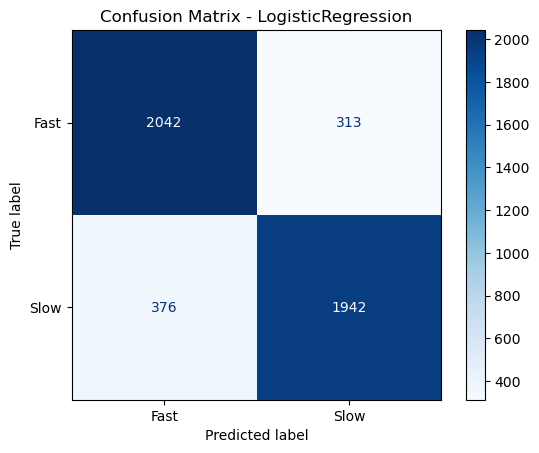


Model: DecisionTreeClassifier
Number of Features: 10
Training Accuracy: 0.859
Test Accuracy: 0.850
Macro F1: 0.850
Weighted F1: 0.850
ROC-AUC: 0.928
PR-AUC: 0.926

Classification Report:
              precision    recall  f1-score   support

        Fast       0.85      0.86      0.85      2355
        Slow       0.85      0.84      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



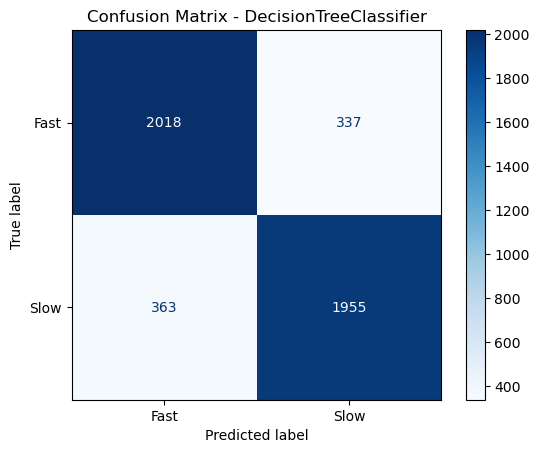


Model: RandomForestClassifier
Number of Features: 10
Training Accuracy: 0.861
Test Accuracy: 0.852
Macro F1: 0.852
Weighted F1: 0.852
ROC-AUC: 0.930
PR-AUC: 0.932

Classification Report:
              precision    recall  f1-score   support

        Fast       0.85      0.85      0.85      2355
        Slow       0.85      0.85      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



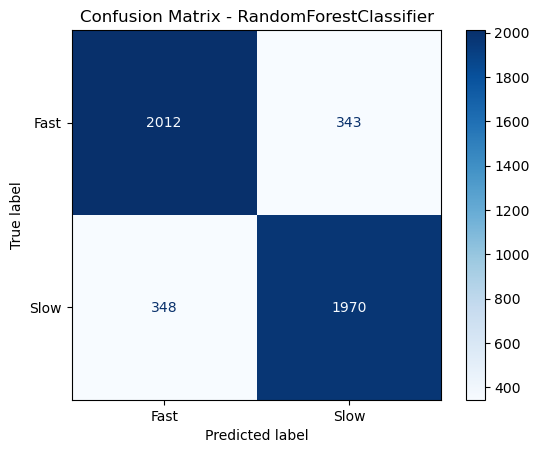

,feature_set,model,num_features,training_accuracy,test_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,MI,LogisticRegression,10,0.854834,0.852557,0.852490,0.852515,0.927345,0.924009
1,MI,DecisionTreeClassifier,10,0.858901,0.850203,0.850176,0.850192,0.928387,0.925869
2,MI,RandomForestClassifier,10,0.861469,0.852129,0.852117,0.852128,0.930480,0.931932


In [423]:
# ==============================
# 1. MI Models
# ==============================

mi_log_reg_results = evaluate_model(
    LogisticRegression(max_iter=2000),
    X_train_mi,
    X_test_mi,
    y_train,
    y_test
)

mi_decision_tree_results = evaluate_model(
    DecisionTreeClassifier(random_state=42, max_depth=6),
    X_train_mi,
    X_test_mi,
    y_train,
    y_test
)

mi_random_forest_results = evaluate_model(
    RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6, n_jobs=-1),
    X_train_mi,
    X_test_mi,
    y_train,
    y_test
)

mi_results_table = pd.DataFrame([
    mi_log_reg_results,
    mi_decision_tree_results,
    mi_random_forest_results
])

mi_results_table.insert(0, "feature_set", "MI")

display(mi_results_table)

## SelectFromModel Models


Model: LogisticRegression
Number of Features: 13
Training Accuracy: 0.857
Test Accuracy: 0.855
Macro F1: 0.855
Weighted F1: 0.855
ROC-AUC: 0.930
PR-AUC: 0.927

Classification Report:
              precision    recall  f1-score   support

        Fast       0.85      0.87      0.86      2355
        Slow       0.86      0.84      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



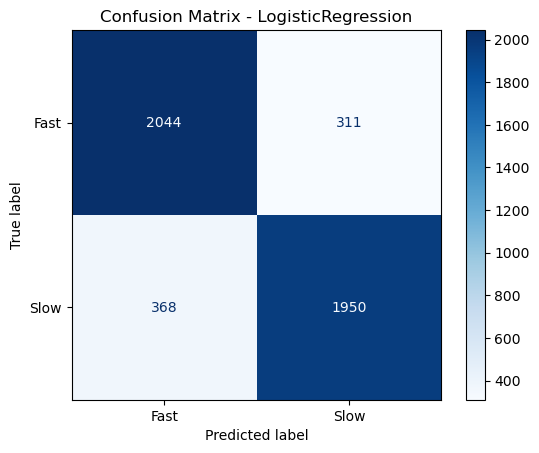


Model: DecisionTreeClassifier
Number of Features: 13
Training Accuracy: 0.859
Test Accuracy: 0.851
Macro F1: 0.851
Weighted F1: 0.851
ROC-AUC: 0.928
PR-AUC: 0.924

Classification Report:
              precision    recall  f1-score   support

        Fast       0.86      0.84      0.85      2355
        Slow       0.84      0.86      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



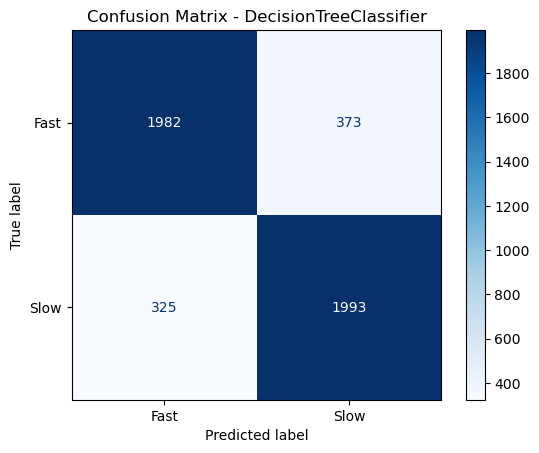


Model: RandomForestClassifier
Number of Features: 13
Training Accuracy: 0.862
Test Accuracy: 0.854
Macro F1: 0.854
Weighted F1: 0.854
ROC-AUC: 0.933
PR-AUC: 0.936

Classification Report:
              precision    recall  f1-score   support

        Fast       0.85      0.86      0.86      2355
        Slow       0.85      0.85      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



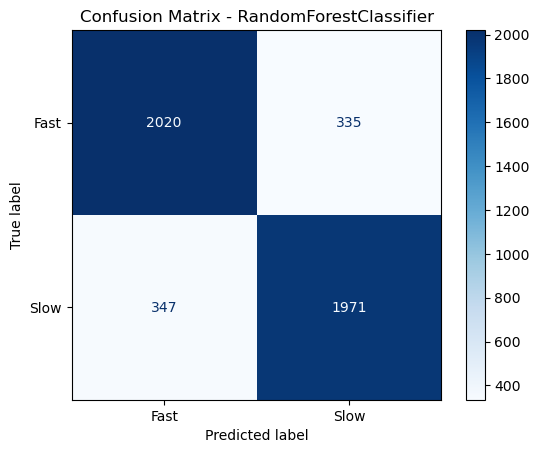

,feature_set,model,num_features,training_accuracy,test_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,SelectFromModel,LogisticRegression,13,0.856600,0.854697,0.854638,0.854662,0.929806,0.926829
1,SelectFromModel,DecisionTreeClassifier,13,0.859061,0.850631,0.850630,0.850628,0.927624,0.924183
2,SelectFromModel,RandomForestClassifier,13,0.862165,0.854055,0.854039,0.854051,0.933426,0.936019


In [424]:
# ==============================
# 2. SelectFromModel Models
# ==============================

sfm_log_reg_results = evaluate_model(
    LogisticRegression(max_iter=2000),
    X_train_sfm,
    X_test_sfm,
    y_train,
    y_test
)

sfm_decision_tree_results = evaluate_model(
    DecisionTreeClassifier(random_state=42, max_depth=6),
    X_train_sfm,
    X_test_sfm,
    y_train,
    y_test
)

sfm_random_forest_results = evaluate_model(
    RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6, n_jobs=-1),
    X_train_sfm,
    X_test_sfm,
    y_train,
    y_test
)

sfm_results_table = pd.DataFrame([
    sfm_log_reg_results,
    sfm_decision_tree_results,
    sfm_random_forest_results
])

sfm_results_table.insert(0, "feature_set", "SelectFromModel")

display(sfm_results_table)

## Model Comparison

Across all three classifiers, performance is highly consistent regardless of feature selection method. The baseline models (25 features) achieve the best performance overall, with Logistic Regression slightly leading (test accuracy $\approx$ 0.856, weighted F1 $\approx$ 0.856). After applying feature selection, both SelectFromModel (13 features) and Mutual Information (10 features) show only a very small decrease in performance, typically within ~0.001–0.003 in weighted F1.

SelectFromModel generally performs slightly better than MI, especially for Logistic Regression and Random Forest, suggesting that model-based feature importance better preserves useful feature interactions. MI, being a univariate method, results in a slightly larger performance drop, but still maintains competitive results. Across all settings, ROC-AUC and PR-AUC remain consistently high (~0.92–0.94), indicating strong discriminative ability regardless of feature subset.

In [425]:
# ==============================
# Combine and Sort Results 
# ==============================

all_results = pd.concat(
    [
        baseline_results,
        sfm_results_table,
        mi_results_table
    ],
    ignore_index=True
)

feature_set_order = {
    "Baseline": 0,
    "SelectFromModel": 1,
    "MI": 2
}

model_order = {
    "LogisticRegression": 0,
    "DecisionTreeClassifier": 1,
    "RandomForestClassifier": 2
}

all_results["feature_set_order"] = all_results["feature_set"].map(feature_set_order)
all_results["model_order"] = all_results["model"].map(model_order)

all_results = all_results.sort_values(
    by=["feature_set_order", "model_order"]
).drop(columns=["feature_set_order", "model_order"])

display(all_results)

,feature_set,model,num_features,training_accuracy,test_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,Baseline,LogisticRegression,25,0.858954,0.855981,0.855920,0.855944,0.930571,0.927947
1,Baseline,DecisionTreeClassifier,25,0.861362,0.853627,0.853626,0.853622,0.927969,0.923940
2,Baseline,RandomForestClassifier,25,0.861095,0.853199,0.853189,0.853179,0.934228,0.937352
3,SelectFromModel,LogisticRegression,13,0.856600,0.854697,0.854638,0.854662,0.929806,0.926829
4,SelectFromModel,DecisionTreeClassifier,13,0.859061,0.850631,0.850630,0.850628,0.927624,0.924183
5,SelectFromModel,RandomForestClassifier,13,0.862165,0.854055,0.854039,0.854051,0.933426,0.936019
6,MI,LogisticRegression,10,0.854834,0.852557,0.852490,0.852515,0.927345,0.924009
7,MI,DecisionTreeClassifier,10,0.858901,0.850203,0.850176,0.850192,0.928387,0.925869
8,MI,RandomForestClassifier,10,0.861469,0.852129,0.852117,0.852128,0.930480,0.931932


# Process Feature Contribution

This section evaluates how much process-related features contribute to predictive performance by removing them and retraining the models under the same experimental setup. The goal is to understand whether the model relies primarily on the initial attributes of a ticket or on information derived from its lifecycle.

Process features are defined as variables that describe how a ticket evolves over time, such as reassignment counts, number of state transitions, and interaction frequency (e.g., `reassignment_count`, `num_events`, `sys_mod_count`). These features may exist in the original dataset or be engineered, but they all capture post-creation behavior rather than initial conditions. As a result, they often contain strong predictive signals but may also reflect information that is not available at the time of prediction, making their contribution important to evaluate separately.

By removing these features, we isolate the effect of static and initial features (e.g., priority, urgency, contact type) and assess whether they are sufficient for accurate prediction.


## Experimental Setup

In [426]:
# ==============================
# Setup: Remove Process Features
# ==============================

process_features = [
    "reassignment_count",
    "reopen_count",
    "sys_mod_count",
    "num_assignment_groups",
    "num_unique_states",
    "num_events",
    "mod_per_event",
    "reassign_per_event",
    "was_reassigned",
    "was_reopened",
    "multi_group"
]

# Drop from original X_train / X_test, NOT processed data
X_train_no_process = X_train.drop(columns=process_features)
X_test_no_process = X_test.drop(columns=process_features)


# ==============================
# Rebuild Feature Types
# ==============================

categorical_cols_np = ["contact_type"]
numeric_cols_np = [
    col for col in X_train_no_process.columns
    if col not in categorical_cols_np
]


# ==============================
# Build New Preprocessor
# ==============================

numeric_pipeline_np = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_np = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_np = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_np, numeric_cols_np),
        ("cat", categorical_pipeline_np, categorical_cols_np)
    ]
)


# ==============================
# Fit on Training Set Only
# ==============================

X_train_np_processed = preprocessor_np.fit_transform(X_train_no_process)
X_test_np_processed = preprocessor_np.transform(X_test_no_process)


# ==============================
# Recover Feature Names
# ==============================

onehot_feature_names_np = preprocessor_np.named_transformers_["cat"] \
    .named_steps["onehot"].get_feature_names_out(categorical_cols_np)

final_feature_names_np = numeric_cols_np + list(onehot_feature_names_np)

X_train_np_processed = pd.DataFrame(
    X_train_np_processed,
    columns=final_feature_names_np,
    index=X_train_no_process.index
)

X_test_np_processed = pd.DataFrame(
    X_test_np_processed,
    columns=final_feature_names_np,
    index=X_test_no_process.index
)

print("Processed training shape:", X_train_np_processed.shape)
print("Processed testing shape:", X_test_np_processed.shape)

display(X_train_np_processed.head())

Processed training shape: (18689, 14)
Processed testing shape: (4673, 14)


,impact,urgency,priority,knowledge,u_priority_confirmation,notify,opened_hour,opened_dayofweek,opened_month,opened_on_weekend,contact_type_Direct opening,contact_type_Email,contact_type_Phone,contact_type_Self service
7829,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,-0.203890,-1.235494,-0.979324,-0.224272,0.0,0.0,1.0,0.0
12426,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,0.535917,-0.605991,0.048911,-0.224272,0.0,0.0,1.0,0.0
4253,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,0.535917,-1.235494,-0.979324,-0.224272,0.0,0.0,1.0,0.0
2789,0.071157,0.034638,-0.010361,2.403391,-0.031901,-0.040097,0.535917,-0.605991,-0.979324,-0.224272,0.0,0.0,1.0,0.0
21347,0.071157,0.034638,-0.010361,-0.416079,-0.031901,-0.040097,1.029122,-1.235494,1.077146,-0.224272,0.0,0.0,1.0,0.0


## Logistic Regression


Model: LogisticRegression
Number of Features: 14
Training Accuracy: 0.624
Test Accuracy: 0.630
Macro F1: 0.627
Weighted F1: 0.627
ROC-AUC: 0.656
PR-AUC: 0.656

Classification Report:
              precision    recall  f1-score   support

        Fast       0.61      0.71      0.66      2355
        Slow       0.65      0.54      0.59      2318

    accuracy                           0.63      4673
   macro avg       0.63      0.63      0.63      4673
weighted avg       0.63      0.63      0.63      4673



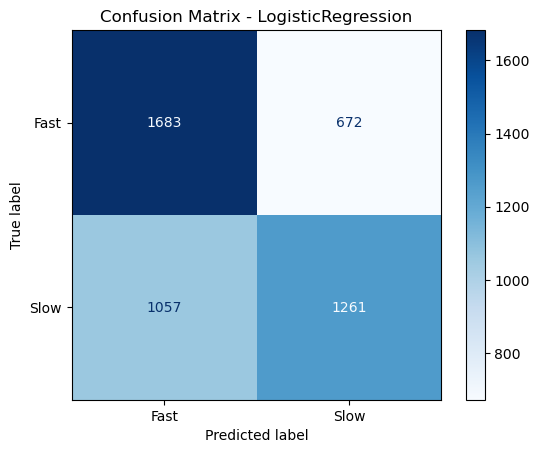

In [427]:
lr_np_results = evaluate_model(
    LogisticRegression(max_iter=2000),
    X_train_np_processed,
    X_test_np_processed,
    y_train,
    y_test
)

## Decision Tree


Model: DecisionTreeClassifier
Number of Features: 14
Training Accuracy: 0.664
Test Accuracy: 0.624
Macro F1: 0.621
Weighted F1: 0.621
ROC-AUC: 0.656
PR-AUC: 0.643

Classification Report:
              precision    recall  f1-score   support

        Fast       0.61      0.71      0.66      2355
        Slow       0.65      0.54      0.59      2318

    accuracy                           0.62      4673
   macro avg       0.63      0.62      0.62      4673
weighted avg       0.63      0.62      0.62      4673



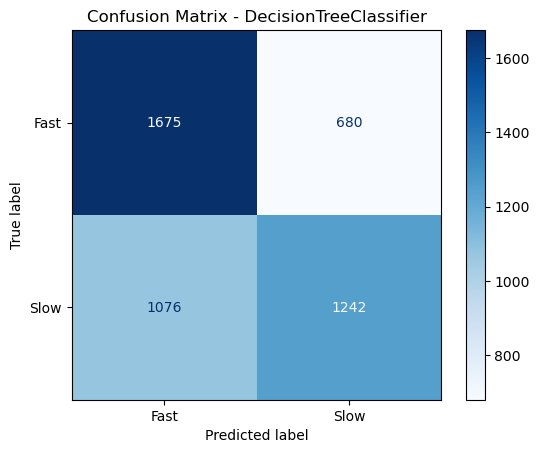

In [428]:
dt_np_results = evaluate_model(
    DecisionTreeClassifier(random_state=42),
    X_train_np_processed,
    X_test_np_processed,
    y_train,
    y_test
)

## Random Forest


Model: RandomForestClassifier
Number of Features: 14
Training Accuracy: 0.636
Test Accuracy: 0.636
Macro F1: 0.627
Weighted F1: 0.627
ROC-AUC: 0.668
PR-AUC: 0.661

Classification Report:
              precision    recall  f1-score   support

        Fast       0.61      0.79      0.69      2355
        Slow       0.69      0.48      0.57      2318

    accuracy                           0.64      4673
   macro avg       0.65      0.63      0.63      4673
weighted avg       0.65      0.64      0.63      4673



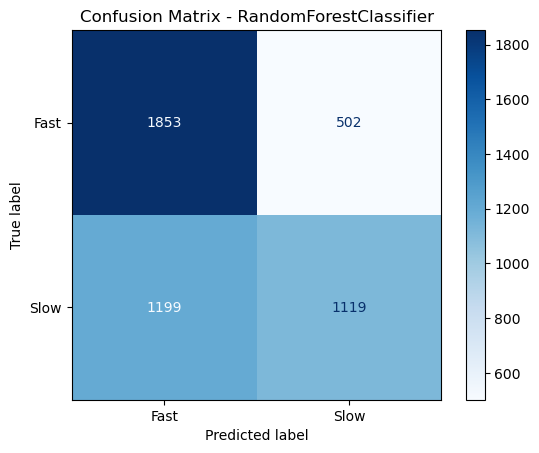

In [429]:
rf_np_results = evaluate_model(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    X_train_np_processed,
    X_test_np_processed,
    y_train,
    y_test
)

## Model Comparison

After removing process-related features, performance drops significantly across all models. Test accuracy decreases from approximately 0.85–0.86 in the baseline setting to around 0.63–0.64, and both Macro F1 and Weighted F1 show similar declines. ROC-AUC and PR-AUC also decrease substantially, indicating a reduced ability to distinguish between classes. Despite this drop, the relative behavior of the models remains consistent. Logistic Regression, Decision Tree, and Random Forest all perform similarly, with only minor differences in performance. Random Forest achieves slightly higher ROC-AUC, while Logistic Regression and Decision Tree exhibit comparable accuracy and F1 scores. The reduced gap between training and testing accuracy suggests that the models are no longer overfitting, but this comes at the cost of significantly weaker predictive power.


The results clearly show that process-related features are critical for model performance. The substantial decline in all evaluation metrics after their removal indicates that these features contain most of the predictive signal in the dataset. In contrast, the remaining static features alone are insufficient to accurately predict the target. This finding suggests that the problem is heavily driven by workflow complexity and ticket handling behavior rather than initial ticket attributes. While process features improve predictive performance, their use should be carefully considered depending on the application context, as they may not always be available at prediction time.

In [430]:
rq3_results = pd.DataFrame([
    lr_np_results,
    dt_np_results,
    rf_np_results
])

rq3_results.insert(0, "feature_set", "No Process Features")

display(rq3_results)

,feature_set,model,num_features,training_accuracy,test_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,No Process Features,LogisticRegression,14,0.624003,0.630002,0.626960,0.627227,0.656281,0.656273
1,No Process Features,DecisionTreeClassifier,14,0.664080,0.624224,0.620970,0.621248,0.656033,0.643466
2,No Process Features,RandomForestClassifier,14,0.636417,0.635994,0.626786,0.627250,0.668347,0.660672


# Model Optimization

In this section, we improve model performance by tuning key hyperparameters for each classifier using Grid Search with cross-validation. For Logistic Regression, we adjust the regularization strength and penalty mix; for Decision Tree and Random Forest, we control model complexity through parameters such as tree depth and minimum samples per leaf. All tuning is performed on the training set using consistent evaluation metrics to ensure fair comparison. This process helps identify parameter settings that improve generalization while avoiding overfitting.

## Logistic Regression

Best LR params: {'C': 1, 'l1_ratio': 0.8, 'solver': 'saga'}

Model: LogisticRegression
Number of Features: 25
Training Accuracy: 0.859
Test Accuracy: 0.856
Macro F1: 0.856
Weighted F1: 0.856
ROC-AUC: 0.931
PR-AUC: 0.928

Classification Report:
              precision    recall  f1-score   support

        Fast       0.85      0.87      0.86      2355
        Slow       0.86      0.84      0.85      2318

    accuracy                           0.86      4673
   macro avg       0.86      0.86      0.86      4673
weighted avg       0.86      0.86      0.86      4673



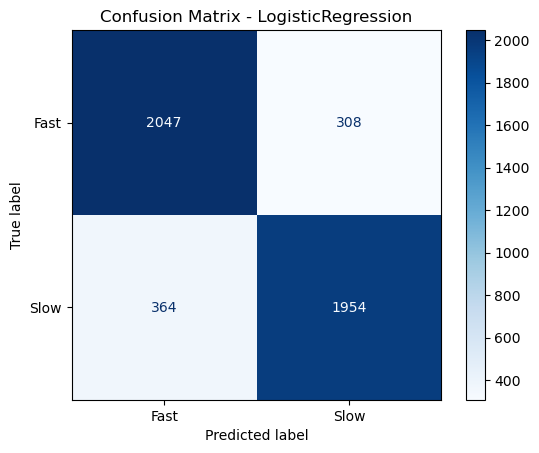

In [431]:
param_grid_lr = [
    # Pure L2 (default behavior)
    {
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "solver": ["lbfgs"]
    },

    # Elastic Net (covers L1 + L2)
    {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["saga"],
        "l1_ratio": [0, 0.2, 0.5, 0.8, 1]
    }
]

lr = LogisticRegression(max_iter=2000)

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_lr.fit(X_train_processed, y_train)

print("Best LR params:", grid_lr.best_params_)

results_lr_opt = evaluate_model(
    grid_lr.best_estimator_,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Decision Tree

Best DT params: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 10, 'min_samples_split': 2}

Model: DecisionTreeClassifier
Number of Features: 25
Training Accuracy: 0.873
Test Accuracy: 0.851
Macro F1: 0.851
Weighted F1: 0.851
ROC-AUC: 0.925
PR-AUC: 0.919

Classification Report:
              precision    recall  f1-score   support

        Fast       0.85      0.86      0.85      2355
        Slow       0.86      0.84      0.85      2318

    accuracy                           0.85      4673
   macro avg       0.85      0.85      0.85      4673
weighted avg       0.85      0.85      0.85      4673



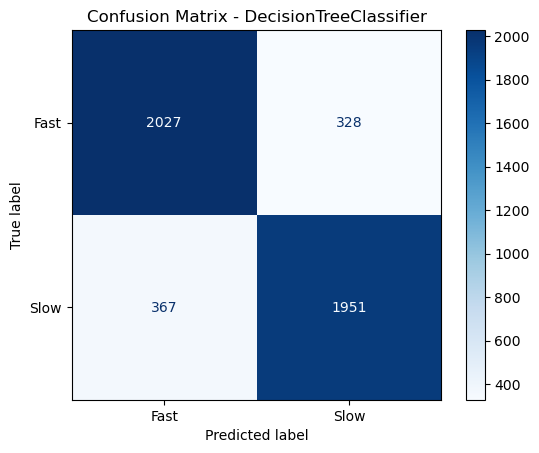

In [432]:
param_grid_dt = {
    "max_depth": [3, 5, 6, 7, 9, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_dt.fit(X_train_processed, y_train)

print("Best DT params:", grid_dt.best_params_)

results_dt_opt = evaluate_model(
    grid_dt.best_estimator_,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Random Forest

Best RF params: {'max_depth': 8, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 100}

Model: RandomForestClassifier
Number of Features: 25
Training Accuracy: 0.881
Test Accuracy: 0.860
Macro F1: 0.860
Weighted F1: 0.860
ROC-AUC: 0.936
PR-AUC: 0.938

Classification Report:
              precision    recall  f1-score   support

        Fast       0.87      0.85      0.86      2355
        Slow       0.85      0.87      0.86      2318

    accuracy                           0.86      4673
   macro avg       0.86      0.86      0.86      4673
weighted avg       0.86      0.86      0.86      4673



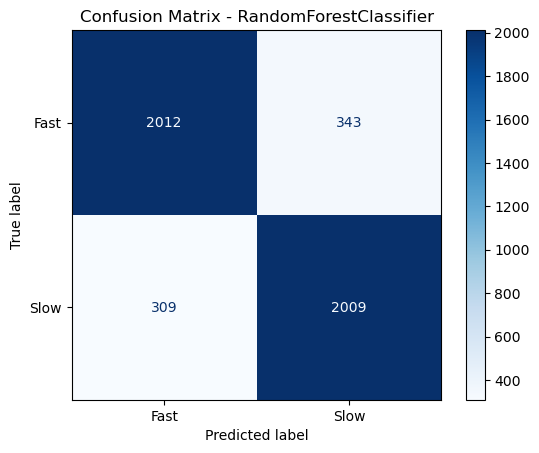

In [433]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", None]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_rf.fit(X_train_processed, y_train)

print("Best RF params:", grid_rf.best_params_)

results_rf_opt = evaluate_model(
    grid_rf.best_estimator_,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

## Model Comparison

After hyperparameter tuning, performance improvements are modest across all models. Random Forest achieves the best overall performance, with the highest test accuracy and F1 scores, indicating that controlled model complexity (e.g., limited depth) helps improve generalization. Logistic Regression remains highly competitive and stable, with performance nearly identical to its baseline, suggesting it was already well-optimized. In contrast, Decision Tree shows slightly lower performance and a larger gap between training and testing accuracy, indicating mild overfitting even after tuning.

Overall, the results show that optimization provides limited gains, and model performance is primarily driven by feature quality rather than hyperparameter tuning.

In [434]:
rq4_results = pd.DataFrame([
    results_lr_opt,
    results_dt_opt,
    results_rf_opt
])

rq4_results.insert(0, "feature_set", "Optimized(Baseline)")

display(rq4_results)

,feature_set,model,num_features,training_accuracy,test_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,Optimized(Baseline),LogisticRegression,25,0.859115,0.856195,0.856138,0.856161,0.930525,0.927737
1,Optimized(Baseline),DecisionTreeClassifier,25,0.873027,0.851273,0.851234,0.851253,0.925069,0.919006
2,Optimized(Baseline),RandomForestClassifier,25,0.880839,0.860475,0.860475,0.860476,0.936267,0.938091


# Final Model Comparison

This section combines results from all experiments to compare how baseline models, feature selection, process-feature removal, and model optimization affect performance. This final table helps identify which modeling strategy gives the best predictive performance and which feature sets are most important.

In [435]:
# ==============================
# Final Model Comparison
# ==============================

final_results = pd.concat(
    [
        baseline_results,
        sfm_results_table,
        mi_results_table,
        rq3_results,
        rq4_results
    ],
    ignore_index=True
)

feature_set_order = {
    "Baseline": 0,
    "SelectFromModel": 1,
    "MI": 2,
    "No Process Features": 3,
    "Optimized(Baseline)": 4
}

model_order = {
    "LogisticRegression": 0,
    "DecisionTreeClassifier": 1,
    "RandomForestClassifier": 2
}

final_results["feature_set_order"] = final_results["feature_set"].map(feature_set_order)
final_results["model_order"] = final_results["model"].map(model_order)

final_results = final_results.sort_values(
    by=["feature_set_order", "model_order"]
).drop(columns=["feature_set_order", "model_order"])

display(final_results)

,feature_set,model,num_features,training_accuracy,test_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,Baseline,LogisticRegression,25,0.858954,0.855981,0.855920,0.855944,0.930571,0.927947
1,Baseline,DecisionTreeClassifier,25,0.861362,0.853627,0.853626,0.853622,0.927969,0.923940
2,Baseline,RandomForestClassifier,25,0.861095,0.853199,0.853189,0.853179,0.934228,0.937352
3,SelectFromModel,LogisticRegression,13,0.856600,0.854697,0.854638,0.854662,0.929806,0.926829
4,SelectFromModel,DecisionTreeClassifier,13,0.859061,0.850631,0.850630,0.850628,0.927624,0.924183
5,SelectFromModel,RandomForestClassifier,13,0.862165,0.854055,0.854039,0.854051,0.933426,0.936019
6,MI,LogisticRegression,10,0.854834,0.852557,0.852490,0.852515,0.927345,0.924009
7,MI,DecisionTreeClassifier,10,0.858901,0.850203,0.850176,0.850192,0.928387,0.925869
8,MI,RandomForestClassifier,10,0.861469,0.852129,0.852117,0.852128,0.930480,0.931932
9,No Process Features,LogisticRegression,14,0.624003,0.630002,0.626960,0.627227,0.656281,0.656273


# Conclusion

This project investigates the effectiveness of machine learning models for predicting incident resolution time and evaluates the impact of feature selection, process-related features, and model optimization.

For **RQ1 (Baseline Prediction)**, all three models achieve strong and consistent performance (test accuracy $\approx$ 0.85–0.86), demonstrating that incident resolution time can be predicted reliably using the available features. Logistic Regression performs slightly better and shows stable generalization, indicating that the underlying relationships are largely linear and well captured by a simple model.

For **RQ2 (Feature Selection)**, both Mutual Information and SelectFromModel significantly reduce the number of features (from 25 to 10–13) while maintaining nearly identical performance. Only 2 out of 10 pairs of highly correlated features are remained. This shows that many features are redundant and that a compact subset is sufficient. SelectFromModel performs slightly better than Mutual Information, suggesting that considering feature interactions is beneficial.

For **RQ3 (Process Feature Contribution)**, removing process-related features leads to a substantial drop in performance (accuracy decreases to $\approx$ 0.63–0.64). This indicates that process features, which capture the lifecycle and handling complexity of incidents, are the primary drivers of predictive performance. Without them, the remaining static features are insufficient for accurate prediction.

For **RQ4 (Model Optimization)**, hyperparameter tuning results in only marginal improvements. Random Forest shows slight gains after controlling model complexity, while Logistic Regression remains largely unchanged, confirming that it was already near optimal. Overall, optimization has limited impact compared to feature design.

In summary, the results show that **feature quality—especially process-related features—plays a more critical role than model complexity or hyperparameter tuning**. A simple model such as Logistic Regression, combined with well-engineered features, achieves strong and stable performance, while more complex models or extensive tuning provide limited additional benefit.